In [2]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\halim\appdata\local\temp\pip-req-build-aele38mr
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for segment_anything: filename=segment_anything-1.0-py3-none-any.whl size=36839 sha256=211e5c08962be99f83f2feaacc7953f2ec40b6eeb22ac1c8be196253c411bb4c
  Stored in directory: C:\Users\halim\AppData\Local\Temp\pip-ephem-wheel-cache-4cfzrfw6\wheels\15\d7\bd\05f5f23b7dcbe70cbc6783b06f12143b0cf1a5da5c7b52dcc5
Successfully built segment_anything


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\halim\AppData\Local\Temp\pip-req-build-aele38mr'

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\halim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124 



[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\halim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/cu124
  Using cached https://download.pytorch.org/whl/cu124/torch-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cu124/torchvision-0.21.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu124/torchaudio-2.6.0%2Bcu124-cp311-cp311-win_amd64.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/filelock-3.13.1-py3-none-any.whl.metadata (2.8 kB)
  Using cached https://download.pytorch.org/whl/networkx-3.3-py3-none-any.whl.metadata (5.1 kB)
  Using cached https://download.pytorch.org/whl/Jinja2-3.1.4-py3-none-any.whl.metadata (2.6 kB)
  Using cached https://download.pytorch.org/whl/fsspec-2024.6.1-py3-none-any.whl.metadata (11 kB)
  Using cached https://download.pytorch.org/whl/sympy-1.13.1-py3-none-any.whl (6.2 MB)
  Using cached https://download.pytorch.org/whl/mpmath-1.3.0-py3-none-any.whl (536 kB)
  Using cache

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2

[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\halim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install opencv-python laspy 

   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.5 MB 1.4 MB/s eta 0:00:29
   ---------------------------------------- 0.1/39.5 MB 1.4 MB/s eta 0:00:28
   ---------------------------------------- 0.3/39.5 MB 2.1 MB/s eta 0:00:19
   ---------------------------------------- 0.4/39.5 MB 2.4 MB/s eta 0:00:17
    --------------------------------------- 0.6/39.5 MB 2.8 MB/s eta 0:00:15
    --------------------------------------- 0.8/39.5 MB 3.0 MB/s eta 0:00:14
    --------------------------------------- 1.0/39.5 MB 3.1 MB/s eta 0:00:13
   - -------------------------------------- 1.2/39.5 MB 3.3 MB/s eta 0:00:12
   - -------------------------------------- 1.4/39.5 MB 3.3 MB/s eta 0:00:12
   - -------------------------------------- 1.5/39.5 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.7/39.5 MB 3.4 MB/s eta 0:00:11
   - -------------------------------------- 1.9/39.5 MB 3.5 MB/s eta 0:00:11
   -- 


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: C:\Users\halim\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
# The Base libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import laspy

# The Deep Learning libraries
import torch
from segment_anything import sam_model_registry
from segment_anything import SamAutomaticMaskGenerator

In [5]:
MODEL = "sam_vit_h_4b8939.pth"


#Choose between cpu or cuda training. For cpu, input 'cpu' instead 'cuda:0'
USED_D = torch.device('cpu')

In [7]:
sam = sam_model_registry["vit_h"](checkpoint = MODEL)

#Cast your model to a specific device (cuda or cpu)
sam.to(device = USED_D)

Sam(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-31): 32 x Block(
        (norm1): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=1280, out_features=3840, bias=True)
          (proj): Linear(in_features=1280, out_features=1280, bias=True)
        )
        (norm2): LayerNorm((1280,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=1280, out_features=5120, bias=True)
          (lin2): Linear(in_features=5120, out_features=1280, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(1280, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sam_masks(anns, custom_colors=None):
    if len(anns) == 0:
        return

    sorted_anns = sorted(anns, key=lambda x: x['area'], reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)
    c_mask = []

    for ann in sorted_anns:
        m = ann['segmentation']
        img = np.ones((m.shape[0], m.shape[1], 3))

        # Ensure each annotation has an ID
        mask_id = ann.get('id')  # If 'id' doesn't exist, it will be None

        # Assign a color: use custom color if provided, else generate random
        if custom_colors and mask_id in custom_colors:
            #print(custom_colors)
            color_mask = custom_colors[mask_id]  # Use user-defined color
        else:
            color_mask = np.random.rand(3).tolist()  # Generate a random color

        # Apply color
        for i in range(3):
            img[:, :, i] = color_mask[i]

        # Overlay mask with transparency
        ax.imshow(np.dstack((img, m)))  # 0.5 transparency for visibility
        c_mask.append(img)

    return c_mask


In [9]:
mask_generator = SamAutomaticMaskGenerator(sam, points_per_batch=16)

In [10]:
def generate_spherical_image(center_coordinates, point_cloud, colors, resolution_y=500):
    # Translate the point cloud by the negation of the center coordinates
    translated_points = point_cloud - center_coordinates

    # Convert 3D point cloud to spherical coordinates
    theta = np.arctan2(translated_points[:, 1], translated_points[:, 0])
    phi = np.arccos(translated_points[:, 2] / np.linalg.norm(translated_points, axis=1))

    # Map spherical coordinates to pixel coordinates
    x = (theta + np.pi) / (2 * np.pi) * (2 * resolution_y)
    y = phi / np.pi * resolution_y

     # Create the spherical image with RGB channels
    resolution_x = 2 * resolution_y
    image = np.zeros((resolution_y, resolution_x, 3), dtype=np.uint8)

    # Create the mapping between point cloud and image coordinates
    mapping = np.full((resolution_y, resolution_x), -1, dtype=int)

    # Assign points to the image pixels
    for i in range(len(translated_points)):
        ix = np.clip(int(x[i]), 0, resolution_x - 1)
        iy = np.clip(int(y[i]), 0, resolution_y - 1)
        if mapping[iy, ix] == -1 or np.linalg.norm(translated_points[i]) < np.linalg.norm(translated_points[mapping[iy, ix]]):
            mapping[iy, ix] = i
            image[iy, ix] = colors[i]
    return image,mapping

In [15]:
#Loading the las file from the disk
las = laspy.read("../../newDataScans/subsampled-scans_000006 - Cloud.las")

#Transforming to a numpy array
coords = np.vstack((las.x, las.y, las.z))
point_cloud = coords.transpose()

#Gathering the colors
r=(las.red/65535*255).astype(int)
g=(las.green/65535*255).astype(int)
b=(las.blue/65535*255).astype(int)
colors = np.vstack((r,g,b)).transpose()

In [17]:
def compute_bounding_box_center(points):
    min_coords = np.min(points, axis=0)
    max_coords = np.max(points, axis=0)
    return (min_coords + max_coords) / 2

In [19]:
resolution = 500

#Defining the position in the point cloud to generate a panorama
points = np.vstack((las.x, las.y, las.z)).T
center_points=compute_bounding_box_center(points)

center_coordinates = [center_points[0] ,center_points[1] , center_points[2]]

x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)

# Compute centroid
centroid = np.array([x.mean(), y.mean(), z.mean()])

print(centroid)

[-29.82404243   2.73019038   1.67330822]


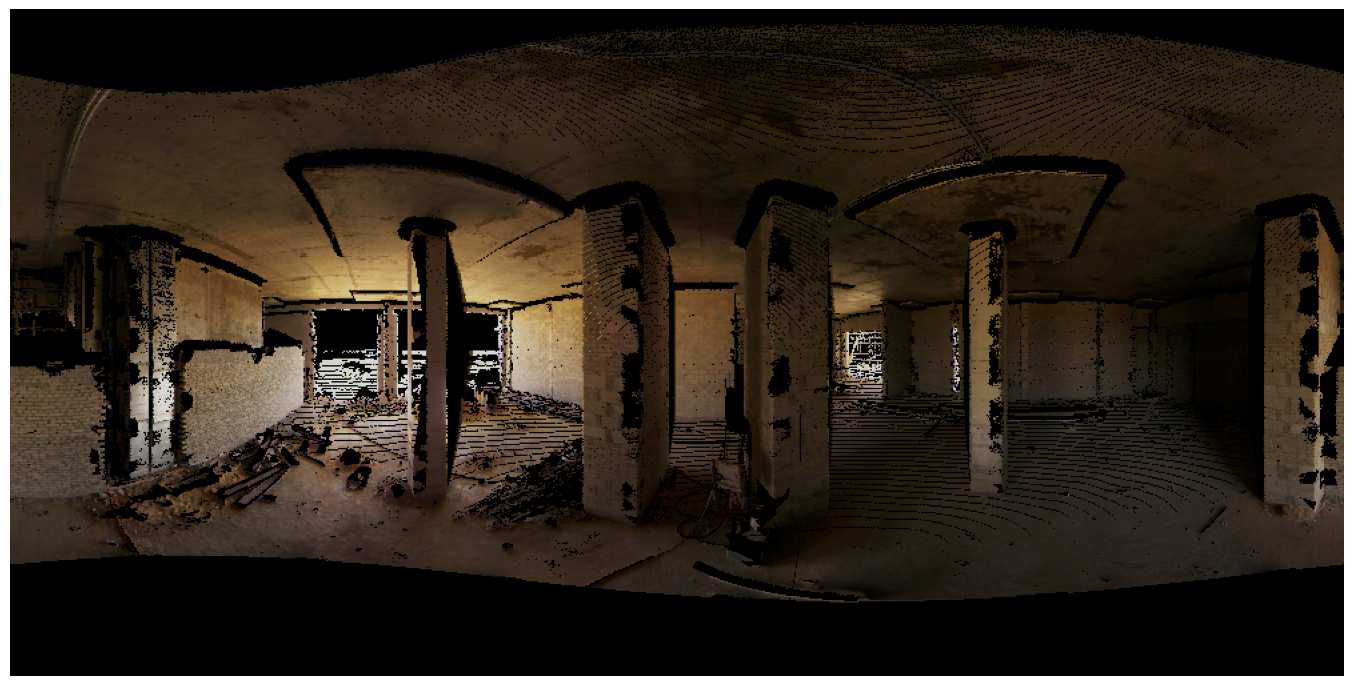

In [21]:
spherical_image, mapping = generate_spherical_image(centroid, point_cloud, colors, resolution)

#Plotting with matplotlib
fig = plt.figure(figsize=(np.shape(spherical_image)[1]/75, np.shape(spherical_image)[0]/75))
fig.add_axes([0,0,1,1])
plt.imshow(spherical_image)
plt.axis('off')

#Saving to the disk
plt.savefig("../newImages/scan06test0.73.jpg")

In [27]:
sam = sam_model_registry["vit_h"](checkpoint = MODEL)
sam.to(device = USED_D)

mask_generator = SamAutomaticMaskGenerator(sam, pred_iou_thresh=0.73,stability_score_thresh=0.85,)

temp_img = cv2.imread("../newImages/scan06test0.73.jpg")
image_rgb = cv2.cvtColor(temp_img, cv2.COLOR_BGR2RGB)


result = mask_generator.generate(image_rgb)

print(len(result))
print(result[0].keys())

142
dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


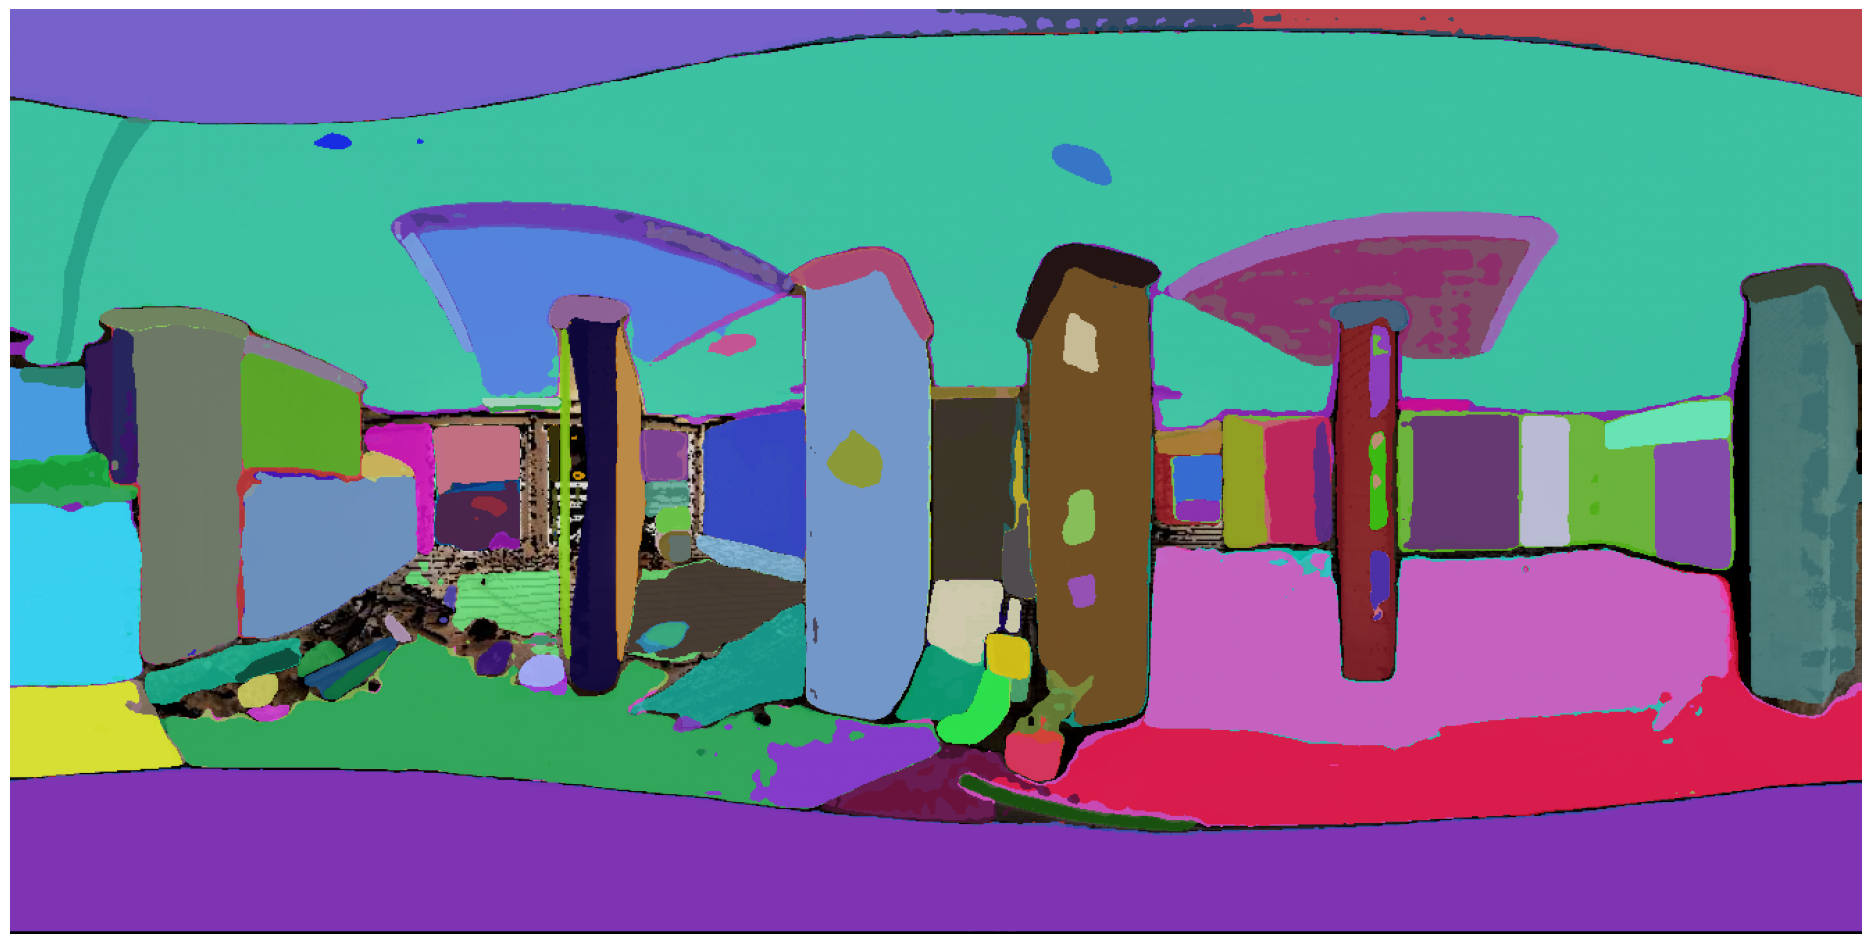

In [30]:
fig = plt.figure(figsize=(np.shape(image_rgb)[1]/72, np.shape(image_rgb)[0]/72))
fig.add_axes([0,0,1,1])

plt.imshow(image_rgb)
color_mask = sam_masks(result)
plt.axis('off')
plt.savefig("../newImages/scan06segmented.jpg")



In [58]:
for idx, ann in enumerate(result):
    ann['id'] = idx  # Assign an ID based on position in the list
    
for ann in result:
    print(f"Assigned ID: {ann['id']}, Area: {ann['area']}, BBox: {ann['bbox']}")


Assigned ID: 0, Area: 56122, BBox: [0, 0, 1332, 82]
Assigned ID: 1, Area: 124030, BBox: [0, 547, 1332, 116]
Assigned ID: 2, Area: 27784, BBox: [570, 174, 91, 337]
Assigned ID: 3, Area: 23439, BBox: [1247, 185, 85, 314]
Assigned ID: 4, Area: 125284, BBox: [0, 492, 1332, 171]
Assigned ID: 5, Area: 252737, BBox: [0, 16, 1332, 284]
Assigned ID: 6, Area: 27493, BBox: [725, 170, 100, 345]
Assigned ID: 7, Area: 2455, BBox: [724, 169, 103, 68]
Assigned ID: 8, Area: 10843, BBox: [953, 210, 50, 272]
Assigned ID: 9, Area: 19752, BBox: [835, 146, 277, 110]
Assigned ID: 10, Area: 6670, BBox: [0, 484, 123, 68]
Assigned ID: 11, Area: 7222, BBox: [665, 280, 58, 130]
Assigned ID: 12, Area: 1912, BBox: [1246, 184, 86, 57]
Assigned ID: 13, Area: 11962, BBox: [0, 355, 94, 131]
Assigned ID: 14, Area: 739, BBox: [757, 346, 23, 39]
Assigned ID: 15, Area: 6803, BBox: [498, 289, 74, 106]
Assigned ID: 16, Area: 28369, BBox: [471, 159, 192, 351]
Assigned ID: 17, Area: 5241, BBox: [446, 428, 126, 88]
Assigned ID:

{1: [0, 0, 0], 2: [0, 0, 0], 3: [0, 0, 0], 4: [0, 0, 0], 5: [0, 0, 0], 6: [0, 0, 0], 7: [0, 0, 0], 8: [0, 0, 0], 0: [0, 0, 0], 9: [0, 0, 0], 10: [0, 0, 0], 11: [0, 0, 0], 12: [0, 0, 0], 13: [0, 0, 0], 14: [0, 0, 0], 15: [0, 0, 0], 16: [0, 0, 0], 17: [0, 0, 0], 18: [0, 0, 0], 19: [0, 0, 0]}
{1: [0, 0, 0], 2: [0, 0, 0], 3: [0, 0, 0], 4: [0, 0, 0], 5: [0, 0, 0], 6: [0, 0, 0], 7: [0, 0, 0], 8: [0, 0, 0], 0: [0, 0, 0], 9: [0, 0, 0], 10: [0, 0, 0], 11: [0, 0, 0], 12: [0, 0, 0], 13: [0, 0, 0], 14: [0, 0, 0], 15: [0, 0, 0], 16: [0, 0, 0], 17: [0, 0, 0], 18: [0, 0, 0], 19: [0, 0, 0]}
{1: [0, 0, 0], 2: [0, 0, 0], 3: [0, 0, 0], 4: [0, 0, 0], 5: [0, 0, 0], 6: [0, 0, 0], 7: [0, 0, 0], 8: [0, 0, 0], 0: [0, 0, 0], 9: [0, 0, 0], 10: [0, 0, 0], 11: [0, 0, 0], 12: [0, 0, 0], 13: [0, 0, 0], 14: [0, 0, 0], 15: [0, 0, 0], 16: [0, 0, 0], 17: [0, 0, 0], 18: [0, 0, 0], 19: [0, 0, 0]}
{1: [0, 0, 0], 2: [0, 0, 0], 3: [0, 0, 0], 4: [0, 0, 0], 5: [0, 0, 0], 6: [0, 0, 0], 7: [0, 0, 0], 8: [0, 0, 0], 0: [0, 0, 0], 

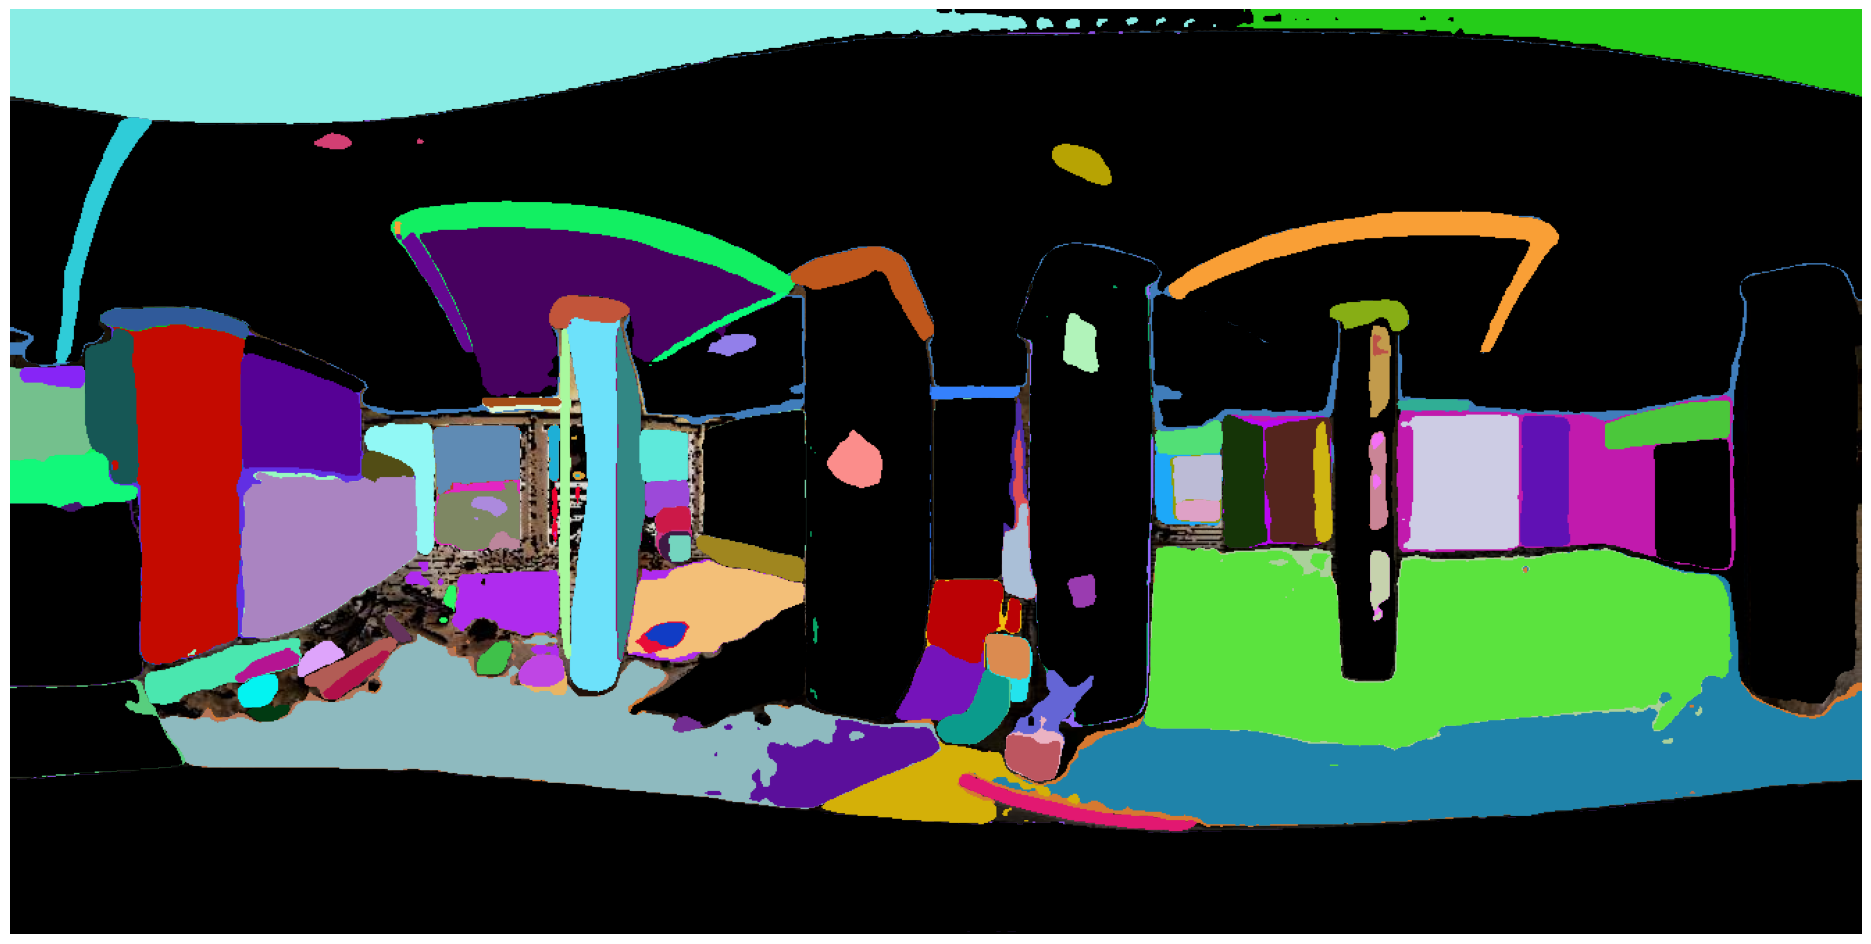

In [84]:
# Define custom colors (e.g., object 18 is red [1, 0, 0])
custom_colors = {
    1: [0, 0, 0],
    2: [0, 0, 0],
    3: [0, 0, 0],
    4: [0, 0, 0],5: [0, 0, 0],
    6: [0, 0, 0],7: [0, 0, 0],
    8: [0, 0, 0],
    0: [0, 0, 0],
    9: [0, 0, 0],
    10: [0, 0, 0],11: [0, 0, 0],
    12: [0, 0, 0],
    13: [0, 0, 0],14: [0, 0, 0],
    15: [0, 0, 0],
    16: [0, 0, 0],17: [0, 0, 0],
    18: [0, 0, 0],
    19: [0, 0, 0],
}

# Generate the masks with the specific color for object 18
fig = plt.figure(figsize=(image_rgb.shape[1] / 72, image_rgb.shape[0] / 72))
fig.add_axes([0, 0, 1, 1])

plt.imshow(image_rgb)

# Apply segmentation masks with custom colors
sam_masks(result, custom_colors)

plt.axis('off')
#plt.savefig("../newImages/scan06segmented.jpg", bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Create folder if it doesn't exist
save_folder = "../../objectScansIou=0.74"
os.makedirs(save_folder, exist_ok=True)

# Loop through all detected masks
for i, mask in enumerate(result):
    bbox = mask["bbox"]  # Bounding box from SAM
    x_min, y_min, width, height = bbox
    x_max, y_max = x_min + width, y_min + height
    print(x_max, y_max)
    #Crop the image using the bounding box
    cropped_image = image_rgb[y_min:y_max+50, x_min:x_max+100]

    # Save the cropped image in the folder
    save_path = os.path.join(save_folder, f"cropped_image_{i}.jpg")  # Change format if needed
    cv2.imwrite(save_path, cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR))  # Convert RGB to BGR for OpenCV

    #print(f"Saved: {save_path}")

  

1332 82
1332 663
661 511
1332 499
1332 663
1332 300
825 515
827 237
1003 482
1112 256
123 552
723 410
1332 241
94 486
780 385
572 395
663 510
572 516
1238 402
255 275
664 238
453 491
663 510
252 335
783 261
1006 231
445 229
487 340
567 246
670 575
292 452
361 478
1332 663
571 412
1107 516
1237 316
91 358
724 409
366 349
366 350
292 465
1332 436
1122 386
332 246
1332 588
871 369
1114 246
1332 62
733 482
169 471
1332 587
904 387
247 471
853 591
1212 574
825 515
867 82
1239 544
738 424
1085 389
489 377
101 254
726 280
457 468
292 480
1236 533
144 552
738 424
486 377
718 529
552 278
485 350
727 472
366 389
58 326
992 439
366 388
268 551
781 430
993 293
1050 289
208 484
732 529
392 389
991 374
735 498
755 555
272 496
536 249
950 385
992 440
248 268
951 387
366 389
872 371
305 392
571 467
288 455
991 374
1241 403
872 356
460 469
571 469
403 467
171 236
627 344
779 554
488 463
769 586
951 383
701 523
487 388
559 256
727 511
400 493
278 496
70 340
758 555
738 423
92 341
398 487
396 286
870 368

In [30]:
def color_point_cloud(image_path, point_cloud, mapping):
    import numpy as np
    import cv2

    # Load the image
    image = cv2.imread(image_path)
    original_h, original_w = image.shape[:2]

    # Resize image to match the mapping size
    image_resized = cv2.resize(image, (mapping.shape[1], mapping.shape[0]))
    resized_h, resized_w = image_resized.shape[:2]

    # Create the modified point cloud
    modified_point_cloud = np.zeros((point_cloud.shape[0], point_cloud.shape[1] + 3), dtype=np.float32)
    modified_point_cloud[:, :3] = point_cloud

    # Assign colors from the resized image to the point cloud
    for iy in range(resized_h):
        for ix in range(resized_w):
            point_index = mapping[iy, ix]

            # Skip invalid indices (-1) and ensure indices are within bounds
            if 0 <= point_index < point_cloud.shape[0]:
                color = image_resized[iy, ix]
                modified_point_cloud[point_index, 3:] = color

    return modified_point_cloud



In [31]:
print("Point cloud shape:", point_cloud.shape)
print("Mapping shape:", mapping.shape)
print("Mapping range:", np.min(mapping), np.max(mapping))

Point cloud shape: (1006596, 3)
Mapping shape: (500, 1000)
Mapping range: -1 999618


In [32]:
image = cv2.imread("spherical_projection_segmented.jpg")
print("Image shape:", image.shape[:2])  # Should match (500, 1000)
print("Mapping shape:", mapping.shape)  # Should be (500, 1000)

Image shape: (654, 1744)
Mapping shape: (500, 1000)


In [33]:
modified_point_cloud = color_point_cloud("spherical_projection_segmented.jpg", point_cloud, mapping)

In [34]:
def export_point_cloud(cloud_path, modified_point_cloud):
    # 1. Create a new header
    header = laspy.LasHeader(point_format=3, version="1.2")
    header.add_extra_dim(laspy.ExtraBytesParams(name="random", type=np.int32))

    # 2. Create a Las
    las_o = laspy.LasData(header)
    las_o.x = modified_point_cloud[:,0]
    las_o.y = modified_point_cloud[:,1]
    las_o.z = modified_point_cloud[:,2]
    las_o.red = modified_point_cloud[:,3]
    las_o.green = modified_point_cloud[:,4]
    las_o.blue = modified_point_cloud[:,5]
    las_o.write(cloud_path)
    
    print("Export succesful at: ", cloud_path)
    return

In [35]:
export_point_cloud("../testingOnMivida/scan01Results2.las", modified_point_cloud)

Export succesful at:  ../testingOnMivida/scan01Results2.las
